In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv("/Users/nikitalondhe/Downloads/BostonHousing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Crime_rate  506 non-null    float64
 1   zn          506 non-null    float64
 2   indus       506 non-null    float64
 3   chas        506 non-null    int64  
 4   nox         506 non-null    float64
 5   rm          501 non-null    float64
 6   Age         506 non-null    float64
 7   Distance    506 non-null    float64
 8   rad         506 non-null    int64  
 9   tax         506 non-null    int64  
 10  ptratio     506 non-null    float64
 11  b           506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [14]:
df.columns

Index(['Crime_rate', 'zn', 'indus', 'chas', 'nox', 'rm', 'Age', 'Distance',
       'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [15]:
df.head(5)

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [16]:
df.isna().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [17]:
df.size

7084

In [55]:
df=df.dropna()

In [56]:
df.isna().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

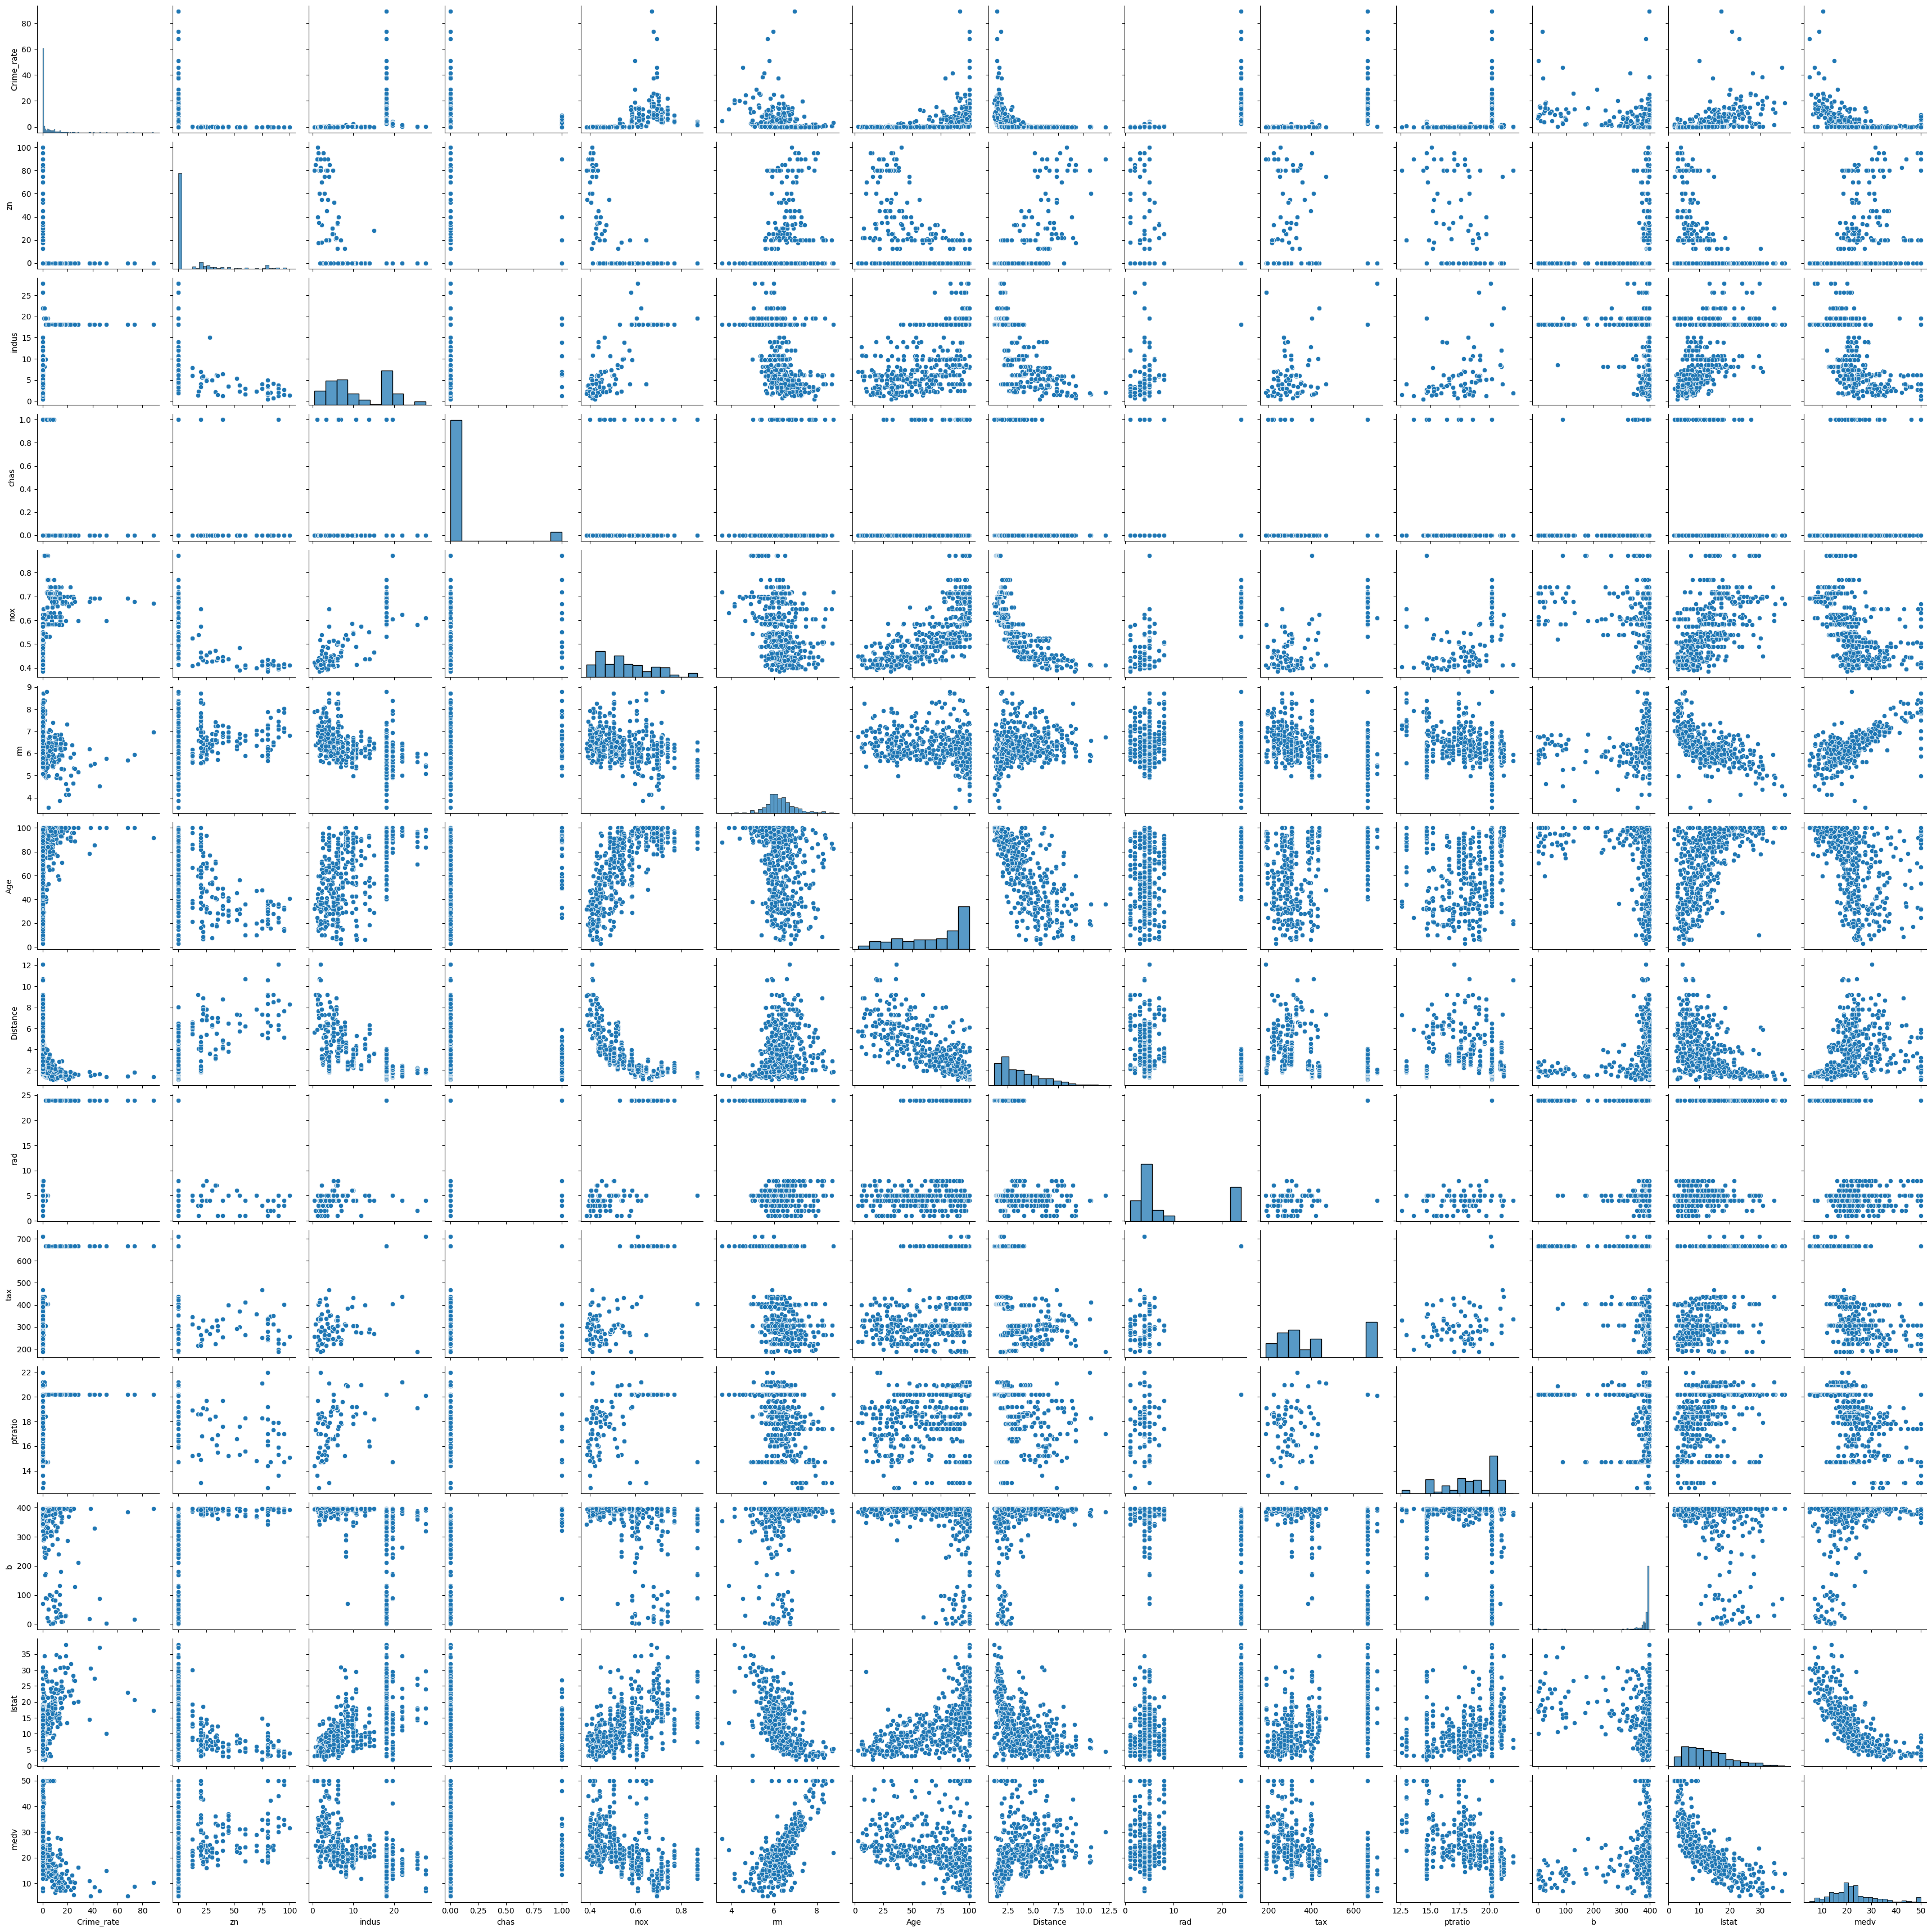

In [57]:
sns.pairplot(df)

<Axes: >

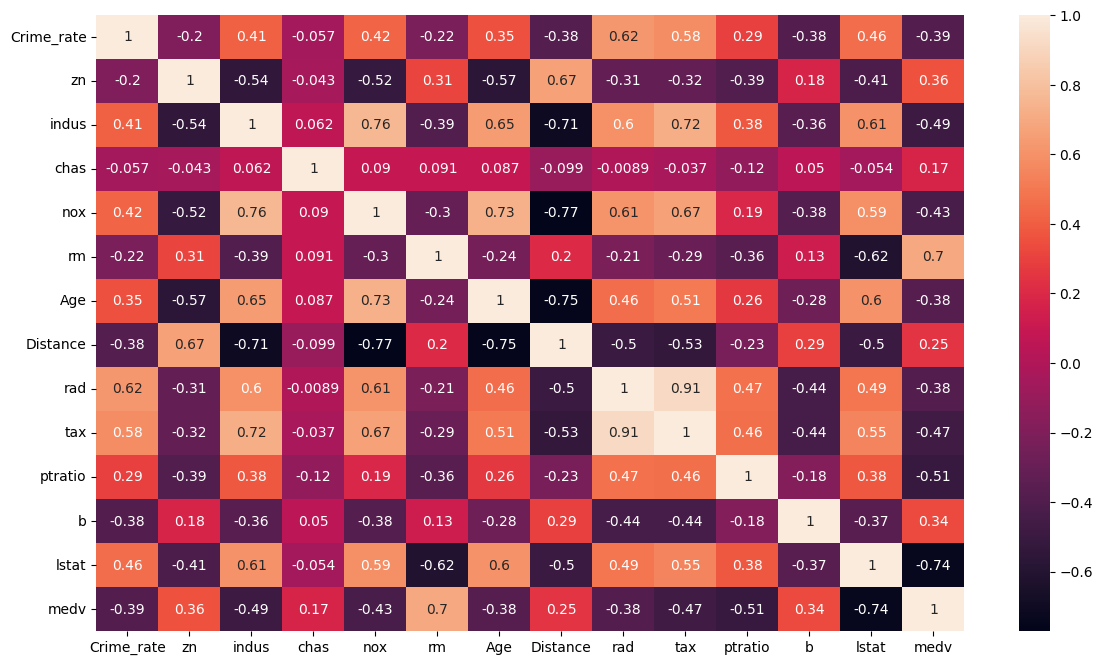

In [58]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(),annot=True)

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
X=df.drop('medv',axis=1)
y=df['medv']

In [61]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [62]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [65]:
model = Sequential()

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))

In [66]:
model.compile(loss='mae',metrics=['mse','mae'],optimizer='adam')

In [67]:
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 22.0707 - mae: 22.0707 - mse: 565.5267  
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.6197 - mae: 21.6197 - mse: 543.2526
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.6968 - mae: 21.6968 - mse: 557.1153
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.6877 - mae: 20.6877 - mse: 500.9512
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 19.4782 - mae: 19.4782 - mse: 458.7012
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.7678 - mae: 18.7678 - mse: 438.5881
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.4570 - mae: 17.4570 - mse: 384.7302
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.0944 - mae: 16.0944 - mse: 327.7372
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15.0083 - mae: 15.0083 - mse: 293.2024 
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12.9606 - mae: 12.9606 - mse: 220.7641
Epoch 11/50
13/13 ━━━━━━━━

In [68]:
metrics=model.evaluate(x_test,y_test ) 
metrics


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5136 - mae: 2.5136 - mse: 13.7211


[2.544908046722412, 14.58763313293457, 2.544908046722412]

In [69]:
y_pred=model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


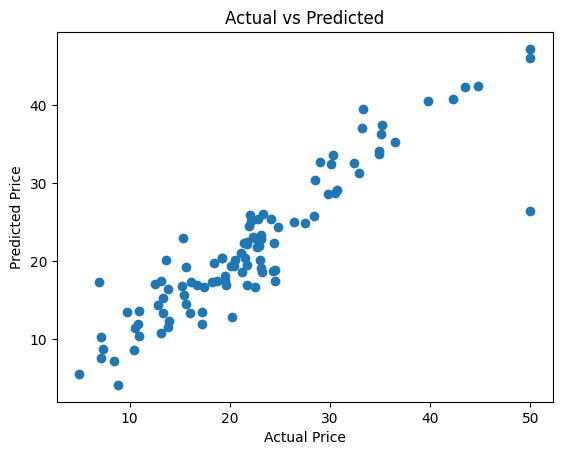

In [70]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()